# The Deutsch-Jozsa algorithm

Deutsch's algorithm outperforms all classical algorithms for a query problem, but the advantage is quite modest: one query versus two.
The Deutsch-Jozsa algorithm extends this advantage — and, in fact, it can be used to solve a couple of different query problems.

Here's a quantum circuit description of the Deutsch-Jozsa algorithm.
An additional classical post-processing step, not shown in the figure, may also be required depending on the specific problem being solved.

![Deutsch-Jozsa algorithm](/learning/images/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/Deutsch-Jozsa.svg)

Of course, we haven't actually discussed what problems this algorithm solves; this is done in the two sections that follow.

## The Deutsch-Jozsa problem

We'll begin with the query problem the Deutsch-Jozsa algorithm was originally intended to solve, which is known as the *Deutsch-Jozsa problem*.

The input function for this problem takes the form $f:\Sigma^n \rightarrow \Sigma$ for an arbitrary positive integer $n.$
Like Deutsch's problem, the task is to output $0$ if $f$ is constant and $1$ if $f$ is balanced, which again means that the number of input strings on which the function takes the value $0$ is equal to the number of input strings on which the function takes the value $1$.

Notice that, when $n$ is larger than $1,$ there are functions of the form $f:\Sigma^n \rightarrow \Sigma$ that are neither constant nor balanced.
For example, the function $f:\Sigma^2\rightarrow\Sigma$ defined as

$$
\begin{aligned}
f(00) & = 0 \\
f(01) & = 0 \\
f(10) & = 0 \\
f(11) & = 1
\end{aligned}
$$

falls into neither of these two categories.
For the Deutsch-Jozsa problem, we simply don't worry about functions like this — they're considered to be "don't care" inputs.
That is, for this problem we have a *promise* that $f$ is either constant or balanced.

<Figure title="Deutsch-Jozsa problem">
  Input: a function $f:\{0,1\}^n\rightarrow\{0,1\}$ \
  Promise: $f$ is either constant or balanced \
  Output: $0$ if $f$ is constant, $1$ if $f$ is balanced
</Figure>

The Deutsch-Jozsa algorithm, with its single query, solves this problem in the following sense:
if every one of the $n$ measurement outcomes is $0,$ then the function $f$ is constant;
and otherwise, if at least one of the measurement outcomes is $1,$ then the function $f$ is balanced.
Another way to say this is that the circuit described above is followed by a classical post-processing step in which the OR of the measurement outcomes is computed to produce the output.

### Algorithm analysis

To analyze the performance of the Deutsch-Jozsa algorithm for the Deutsch-Jozsa problem, it's helpful to begin by thinking about the action of a single layer of Hadamard gates.
A Hadamard operation can be expressed as a matrix in the usual way,

$$
H = \begin{pmatrix}
\frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\[2mm]
\frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}}
\end{pmatrix},
$$

but we can also express this operation in terms of its action on standard basis states:

$$
\begin{aligned}
H \vert 0\rangle & = \frac{1}{\sqrt{2}} \vert 0 \rangle + \frac{1}{\sqrt{2}} \vert 1 \rangle\\[3mm]
H \vert 1\rangle & = \frac{1}{\sqrt{2}} \vert 0 \rangle - \frac{1}{\sqrt{2}} \vert 1 \rangle.
\end{aligned}
$$

These two equations can be combined into a single formula,

$$
H \vert a \rangle = \frac{1}{\sqrt{2}} \vert 0 \rangle + \frac{1}{\sqrt{2}} (-1)^a \vert 1 \rangle
= \frac{1}{\sqrt{2}} \sum_{b\in\{0,1\}} (-1)^{ab} \vert b\rangle,
$$

which is true for both choices of $a\in\Sigma.$

Now suppose that instead of just a single qubit we have $n$ qubits, and a Hadamard operation is performed on each.
The combined operation on the $n$ qubits is described by the tensor product $H\otimes \cdots \otimes H$ ($n$ times), which we write as $H^{\otimes n}$ for conciseness and clarity.
Using the formula from above, followed by expanding and then simplifying, we can express the action of this combined operation on the standard basis states of $n$ qubits like this:

$$
\begin{aligned}
  & H^{\otimes n} \vert x_{n-1} \cdots x_1 x_0 \rangle \\
  & \qquad = \bigl(H \vert x_{n-1} \rangle \bigr) \otimes \cdots \otimes \bigl(H \vert x_{0} \rangle \bigr) \\
  & \qquad = \Biggl( \frac{1}{\sqrt{2}} \sum_{y_{n-1}\in\Sigma} (-1)^{x_{n-1} y_{n-1}} \vert y_{n-1} \rangle \Biggr)
  \otimes \cdots \otimes
  \Biggl( \frac{1}{\sqrt{2}} \sum_{y_{0}\in\Sigma} (-1)^{x_{0} y_{0}} \vert y_{0} \rangle \Biggr) \\
  & \qquad = \frac{1}{\sqrt{2^n}} \sum_{y_{n-1}\cdots y_0 \in \Sigma^n}
  (-1)^{x_{n-1}y_{n-1} + \cdots + x_0 y_0} \vert y_{n-1} \cdots y_0 \rangle.
\end{aligned}
$$

Here, by the way, we're writing binary strings of length $n$ as $x_{n-1}\cdots x_0$ and $y_{n-1}\cdots y_0,$ following Qiskit's indexing convention.

This formula provides us with a useful tool for analyzing the quantum circuit above.
After the first layer of Hadamard gates is performed, the state of the $n+1$ qubits (including the leftmost/bottom qubit, which is treated separately from the rest) is

$$
\bigl( H \vert 1 \rangle \bigr) \bigl( H^{\otimes n} \vert 0 \cdots 0 \rangle \bigr)
= \vert - \rangle \otimes \frac{1}{\sqrt{2^n}} \sum_{x_{n-1}\cdots x_0 \in \Sigma^n} \vert x_{n-1} \cdots x_0 \rangle.
$$

When the $U_f$ operation is performed, this state is transformed into

$$
\vert - \rangle \otimes \frac{1}{\sqrt{2^n}}
\sum_{x_{n-1}\cdots x_0 \in \Sigma^n} (-1)^{f(x_{n-1}\cdots x_0)} \vert x_{n-1} \cdots x_0 \rangle
$$

through exactly the same phase kick-back phenomenon that we saw in the analysis of Deutsch's algorithm.

Then the second layer of Hadamard gates is performed, which (by the formula above) transforms this state into

$$
\vert - \rangle \otimes \frac{1}{2^n}
\sum_{x_{n-1}\cdots x_0 \in \Sigma^n}
\sum_{y_{n-1}\cdots y_0 \in \Sigma^n}
(-1)^{f(x_{n-1}\cdots x_0) + x_{n-1}y_{n-1} + \cdots + x_0 y_0}
\vert y_{n-1} \cdots y_0 \rangle.
$$

This expression looks somewhat complicated, and not too much can be concluded about the probabilities to obtain different measurement outcomes without knowing more about the function $f.$

Fortunately, all we need to know is the probability that every one of the measurement outcomes is $0$ — because that's the probability that the algorithm determines that $f$ is constant.
This probability has a simple formula.

$$
\Biggl\vert
\frac{1}{2^n}
\sum_{x_{n-1}\cdots x_0 \in \Sigma^n}
(-1)^{f(x_{n-1}\cdots x_0)}
\Biggr\vert^2
= \begin{cases}
1 & \text{if $f$ is constant}\\[1mm]
0 & \text{if $f$ is balanced}
\end{cases}
$$

In greater detail, if $f$ is constant, then either $f(x_{n-1}\cdots x_0) = 0$ for every string $x_{n-1}\cdots x_0,$
in which case the value of the sum is $2^n,$ or $f(x_{n-1}\cdots x_0) = 1$ for every string $x_{n-1}\cdots x_0,$
in which case the value of the sum is $-2^n.$
Dividing by $2^n$ and taking the square of the absolute value yields $1.$

If, on the other hand, $f$ is balanced, then $f$ takes the value $0$ on half of the strings $x_{n-1}\cdots x_0$ and the value $1$ on the other half, so the $+1$ terms and $-1$ terms in the sum cancel and we're left with the value $0.$

We conclude that the algorithm operates correctly provided that the promise is fulfilled.

### Classical difficulty

The Deutsch-Jozsa algorithm works every time, always giving us the correct answer when the promise is met, and requires a single query.
How does this compare with classical query algorithms for the Deutsch-Jozsa problem?

First, any *deterministic* classical algorithm that correctly solves the Deutsch-Jozsa problem must make exponentially many queries:
$2^{n-1} + 1$ queries are required in the worst case.
The reasoning is that, if a deterministic algorithm queries $f$ on $2^{n-1}$ or fewer different strings, and obtains the same function value every time, then both answers are still possible.
The function might be constant, or it might be balanced but through bad luck the queries all happen to return the same function value.

The second possibility might seem unlikely — but for deterministic algorithms there's no randomness or uncertainty, so they will fail systematically on certain functions.
We therefore have a significant advantage of quantum over classical algorithms in this regard.

There is a catch, however, which is that *probabilistic* classical algorithms can solve the Deutsch-Jozsa problem with very high probability using just a few queries.
In particular, if we simply choose a few different strings of length $n$ randomly, and query $f$ on those strings, it's unlikely that we'll get the same function value for all of them when $f$ is balanced.

To be specific, if we choose $k$ input strings $x^1,\ldots,x^k \in \Sigma^n$ uniformly at random, evaluate $f(x^1),\ldots,f(x^k),$ and answer $0$ if the function values are all the same, and $1$ if not, then we'll always be correct when $f$ is constant, and wrong in the case that $f$ is balanced with probability just $2^{-k + 1}.$
If we take $k = 11,$ for instance, this algorithm will answer correctly with probability greater than $99.9$%.

For this reason, we do still have a rather modest advantage of quantum over classical algorithms — but it is nevertheless a quantifiable advantage representing an improvement over Deutsch's algorithm.



## Deutsch-Jozsa with Qiskit



In [118]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np

To implement the Deutsch-Jozsa algorithm in Qiskit, we'll start by defining a function `dj_query` that generates a quantum circuit implementing a query gate, for a randomly selected function satisfying the promise for the Deutsch-Jozsa problem.
With a 50% chance, the function is constant, and with 50% change the function is balanced.
For each of those two possibilities, the function is selected uniformly from the functions of that type.
The argument is the number of input bits of the function.



In [121]:
def dj_query(num_qubits):
    # Create a circuit implementing for a query gate for a random function
    # satisfying the promise for the Deutsch-Jozsa problem.

    qc = QuantumCircuit(num_qubits + 1)

    if np.random.randint(0, 2):
        # Flip output qubit with 50% chance
        qc.x(num_qubits)
    if np.random.randint(0, 2):
        # return constant circuit with 50% chance
        return qc

    # Choose half the possible input strings
    on_states = np.random.choice(
        range(2**num_qubits),  # numbers to sample from
        2**num_qubits // 2,  # number of samples
        replace=False,  # makes sure states are only sampled once
    )

    def add_cx(qc, bit_string):
        for qubit, bit in enumerate(reversed(bit_string)):
            if bit == "1":
                qc.x(qubit)
        return qc

    for state in on_states:
        qc.barrier()  # Barriers are added to help visualize how the functions are created.
        qc = add_cx(qc, f"{state:0b}")
        qc.mcx(list(range(num_qubits)), num_qubits)
        qc = add_cx(qc, f"{state:0b}")

    qc.barrier()

    return qc

We can show the quantum circuit implementation of the query gate using the `draw` method as usual.



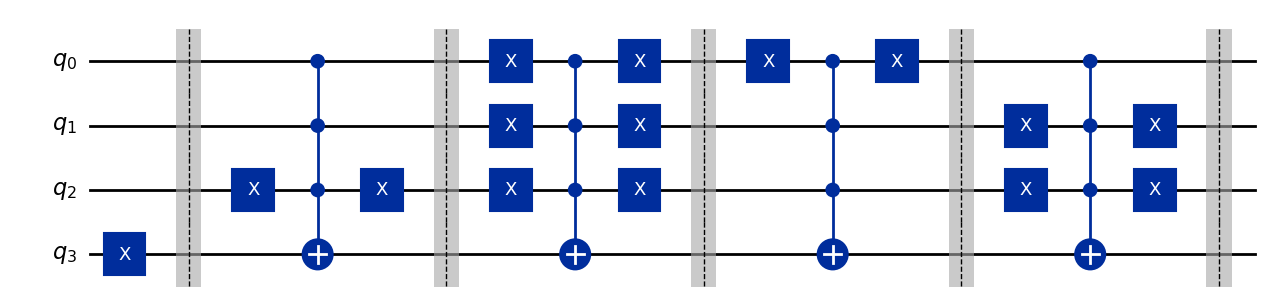

In [124]:
display(dj_query(3).draw(output="mpl"))

Next we define a function that creates the Deutsch-Jozsa circuit, taking a quantum circuit implementation of a query gate as an argument.



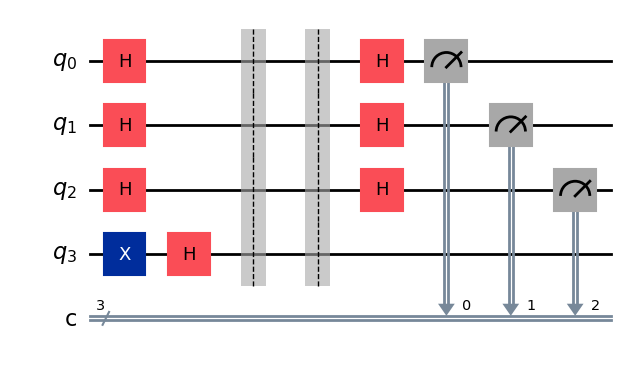

In [127]:
def compile_circuit(function: QuantumCircuit):
    # Compiles a circuit for use in the Deutsch-Jozsa algorithm.

    n = function.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)
    qc.x(n)
    qc.h(range(n + 1))
    qc.compose(function, inplace=True)
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc

qc.draw("mpl")

Finally, a function that runs the Deutsch-Jozsa circuit once is defined.



In [130]:
def dj_algorithm(function: QuantumCircuit):
    # Determine if a function is constant or balanced.

    qc = compile_circuit(function)

    result = AerSimulator().run(qc, shots=1, memory=True).result()
    measurements = result.get_memory()
    if "1" in measurements[0]:
        return "balanced"
    return "constant"
    

We can test our implementation by choosing a function randomly, displaying the quantum circuit implementation of a query gate for this function, and then running the Deutsch-Jozsa algorithm on that function.



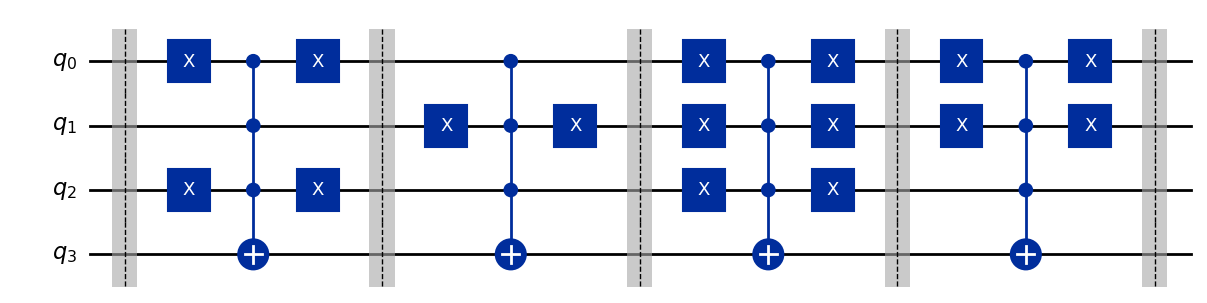

'balanced'

In [135]:
f = dj_query(3)
display(f.draw("mpl"))
display(dj_algorithm(f))

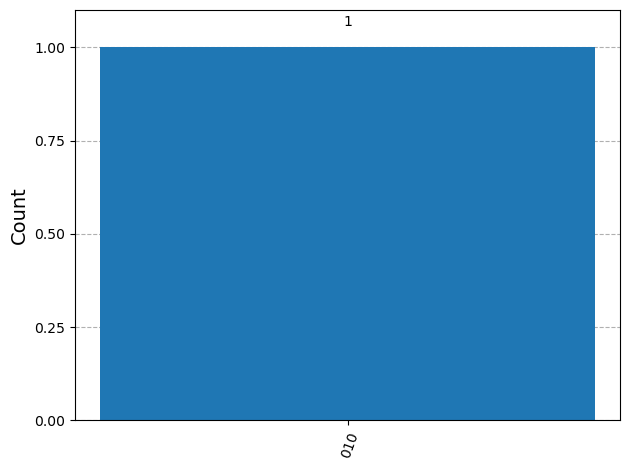

In [137]:
#plotting histogram to visualise the result on simulator
from qiskit.visualization import plot_histogram
# Build the simulator
sim = AerSimulator()

# Reuse the SAME oracle f
qc_sim = compile_circuit(f)

# Run simulator
result_sim = sim.run(qc_sim, shots=1).result()
counts_sim = result_sim.get_counts()

# Display histogram
plot_histogram(counts_sim)


In [139]:
#checking all the hardware available to run the circuit on
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/a3e8fcae3c324eae9efd4e94c6bcef8b:addde511-b5bd-48e6-90e1-5d3fb6ecfb04::",
    token="gQK0zSNL4JdxpuFSJJ6o4cWB4fLwFPJeWfU_Y6jT_onx"
)

print("Connected! Available backends:")
print([b.name for b in service.backends()])


qiskit_runtime_service._discover_account:WARNING:2025-11-28 01:22:09,858: Loading account with the given token. A saved account will not be used.


Connected! Available backends:
['ibm_fez', 'ibm_marrakesh', 'ibm_torino']


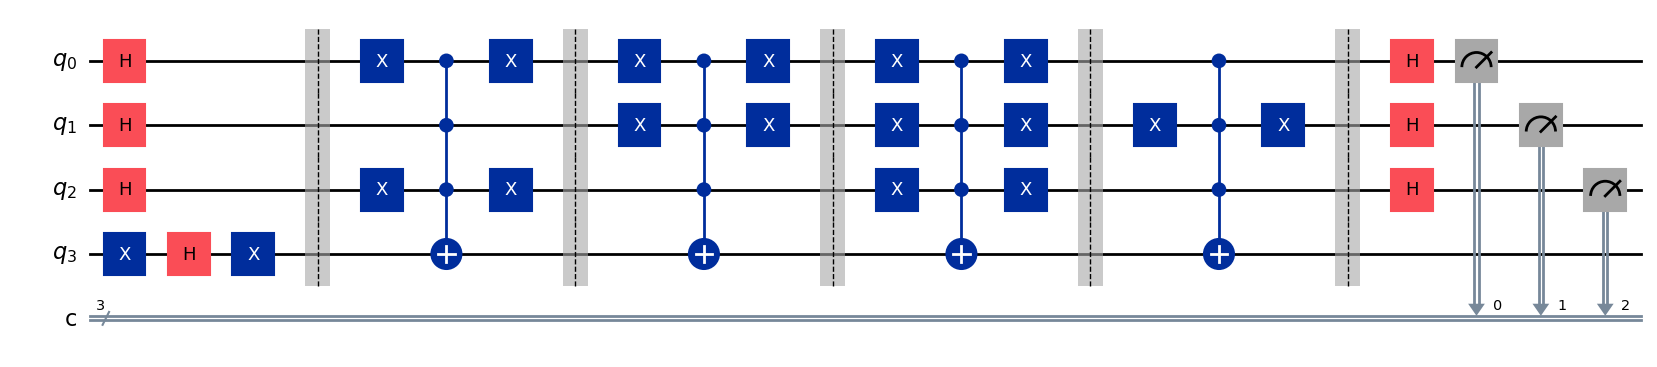

In [141]:
#circuit diagram after circuit compiled for use in Deutsch-Jozsa Algorithm

# Pick an oracle for 3 input qubits
f = dj_query(3)
# Compiled the full Deutsch–Jozsa circuit for that oracle
dj_circuit = compile_circuit(f)
# Draw the full circuit (Hadamards + oracle + final Hadamards + measurement)
dj_circuit.draw('mpl')


In [143]:
#Selecting the hardware to run the circuit on. Chose to run it on ibm_fez
# Load the Qiskit Runtime service
from qiskit_ibm_runtime import QiskitRuntimeService
 
# Load the Runtime primitive and session
from qiskit_ibm_runtime import SamplerV2 as Sampler

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/a3e8fcae3c324eae9efd4e94c6bcef8b:addde511-b5bd-48e6-90e1-5d3fb6ecfb04::",
    token="gQK0zSNL4JdxpuFSJJ6o4cWB4fLwFPJeWfU_Y6jT_onx"
)
 
# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_brisbane".
# backend = service.least_busy(operational=True, simulator=False, min_num_qubits = 127)
backend = service.backend("ibm_fez")
print(backend.name)    #printing the backend being used to run the circuit
 
 
sampler = Sampler(mode=backend)

qiskit_runtime_service._discover_account:WARNING:2025-11-28 01:22:33,329: Loading account with the given token. A saved account will not be used.


ibm_fez


In [145]:
# Transpiling the circuit to run on the IBM Quantum hardware 
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
 
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
 
qc_isa = pm.run(dj_circuit)   #implememting the dj circuit

In [147]:
#Run the job on a real quantum computer
 
job = sampler.run([qc_isa], shots=1)
# job = sampler_sim.run([qc_isa],shots=1) # uncomment this line to run on simulator instead
res = job.result()
counts = res[0].data.c.get_counts()
print(res)   

PrimitiveResult([SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=1, num_bits=3>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([DoubleSliceSpan(<start='2025-11-28 09:22:58', stop='2025-11-28 09:22:59', size=1>)])}, 'version': 2})


In [149]:
# Visualize and analyze the result and interpret whether the result is balanced or constant on quantum computer
 
## Analysis
print(counts)
 
if (
    "0" * n in counts
):  # The D-J algorithm returns all zeroes if the function was constant
    print("constant")
else:
    print("balanced")  # anything other than all zeroes means the function is balanced.

{'110': 1}
balanced


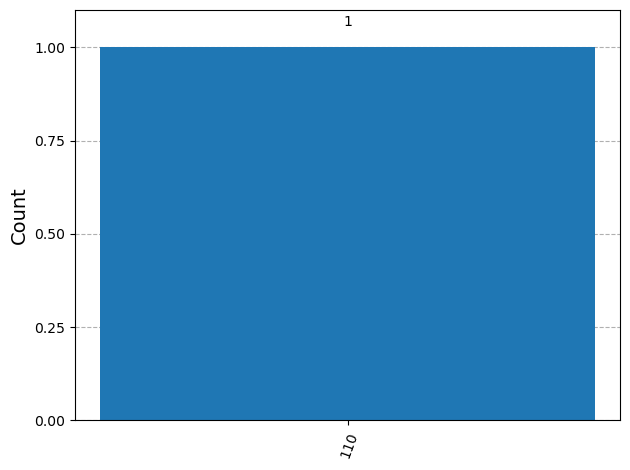

In [151]:
#  Visualize and analyze results for the hardware/ quantum backends using histogram

from qiskit.visualization import plot_histogram
 
plot_histogram(counts)

In [153]:
print("Running on backend:", backend.name, "Simulator?", backend.configuration().simulator)   #checking if the circuit ran on the hardware or simulator
#if result is false, it means the circuit was run on hardware.

Running on backend: ibm_fez Simulator? False


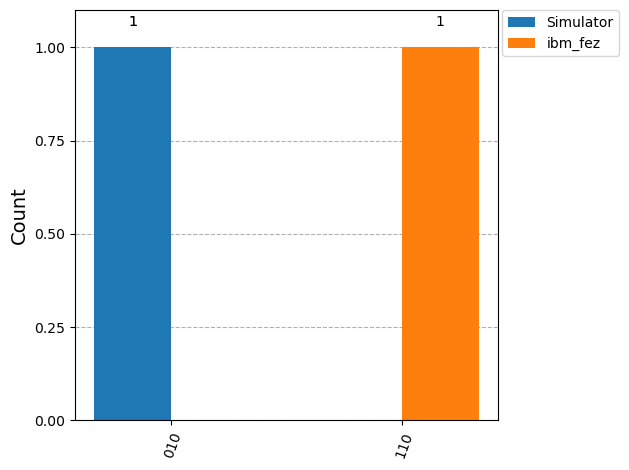

In [155]:
#comparing histograms for both the simulator and the IBM hardware the circuit was run on
# counts_sim from result on simulator, results on counts from hardware run
plot_histogram([counts_sim, counts], legend=["Simulator", backend.name])
